In [1]:
import os
import numpy as np 
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from datetime import datetime
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler

I0000 00:00:1774894280.235902    5944 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
def to_usd(val) -> float:
    return round(val / 1000000, 2)

In [4]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [5]:
data = pd.read_csv("https://raw.githubusercontent.com/AjengSF015/Data-Apple-Stock-Price/refs/heads/main/Apple%20Stock%20Price.csv", delimiter=";")

data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,12/12/1980,128348,128906,128348,128348,99319,469033600
1,15/12/1980,122210,122210,121652,121652,94137,175884800
2,16/12/1980,113281,113281,112723,112723,87228,105728000
3,17/12/1980,115513,116071,115513,115513,89387,86441600
4,18/12/1980,118862,119420,118862,118862,91978,73449600


In [6]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

Text(0.5, 1.0, 'Price over time in $')

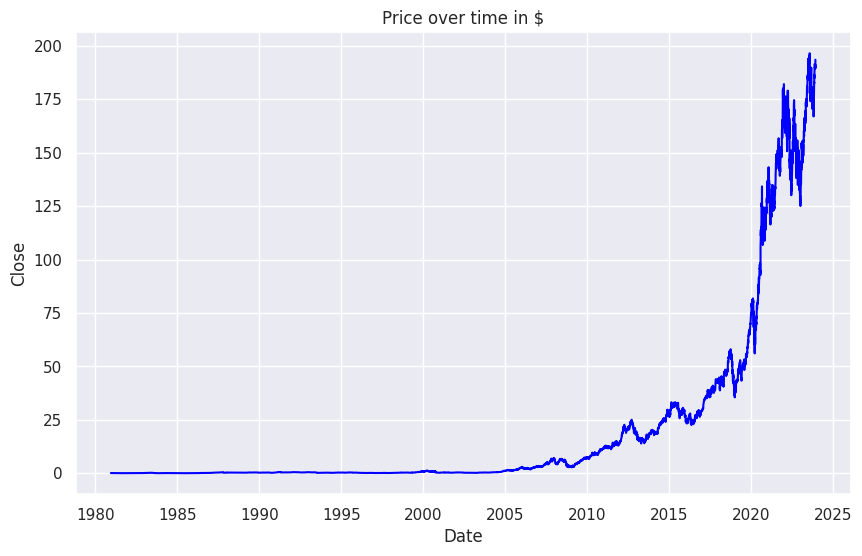

In [7]:
prediction = data.loc[
    (data['Date'] > datetime(2013,8,15)) &
    (data['Date'] < datetime(2013,12,5))
]


sns.set_theme(style="darkgrid", palette='pastel')

plt.subplots(figsize=(10, 6))
sns.lineplot(data=data, x='Date', y=to_usd(data['Close']), color='blue')
plt.title("Price over time in $")

In [8]:
# Prepare for the LSTM Model (Sequential)
stock_close = data.filter(["Close"])
dataset = stock_close.values #convert to numpy array
training_data_len = int(np.ceil(len(dataset) * 0.95))

In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

# scaled_data ()

In [10]:
training_data = scaled_data[:training_data_len]

In [11]:
X_train, y_train = [], []

In [12]:
for i in range(60, len(training_data)):
    X_train.append(training_data[i-60:i, 0])
    y_train.append(training_data[i,0])
    
X_train, y_train = np.array(X_train), np.array(y_train)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [13]:
print(f"Items per sequence: {len(X_train[0])}")
print(f"Count of sequences: {len(X_train)}")

Items per sequence: 60
Count of sequences: 10235


In [14]:
# Build the Model
model = keras.models.Sequential(name="appl_stock_price_lstm")

# Input Layer
model.add(keras.layers.InputLayer(shape=(60, 1)))

# Hidden Layers
model.add(keras.layers.LSTM(64, return_sequences=True))
model.add(keras.layers.LSTM(64, return_sequences=False))
model.add(keras.layers.Dense(128, activation="relu"))
model.add(keras.layers.Dropout(0.5))

# Output Layer
model.add(keras.layers.Dense(1))

# Output Model Info
model.summary()
model.compile(optimizer="adam",
              loss="mae",
              metrics=[keras.metrics.RootMeanSquaredError()])

I0000 00:00:1774894289.626715    5944 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10103 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti, pci bus id: 0000:07:00.0, compute capability: 8.9


Model: "appl_stock_price_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train model on data
training = model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20


I0000 00:00:1774894292.909278    6094 cuda_dnn.cc:461] Loaded cuDNN version 92000


320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0760 - root_mean_squared_error: 0.1620
Epoch 2/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0566 - root_mean_squared_error: 0.1092
Epoch 3/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0518 - root_mean_squared_error: 0.1044
Epoch 4/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0491 - root_mean_squared_error: 0.1013
Epoch 5/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0465 - root_mean_squared_error: 0.1043
Epoch 6/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0435 - root_mean_squared_error: 0.0976
Epoch 7/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0407 - root_mean_squared_error: 0.0967
Epoch 8/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0400 - root_mean_squared_error: 0.0960
Epoch 9/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0385 - root_mean_squared_error: 0.0988
Epoch 10/20
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0376 - root_mean_squared_error: 0.0977


Text(0.5, 1.0, 'Root Mean Squared Error')

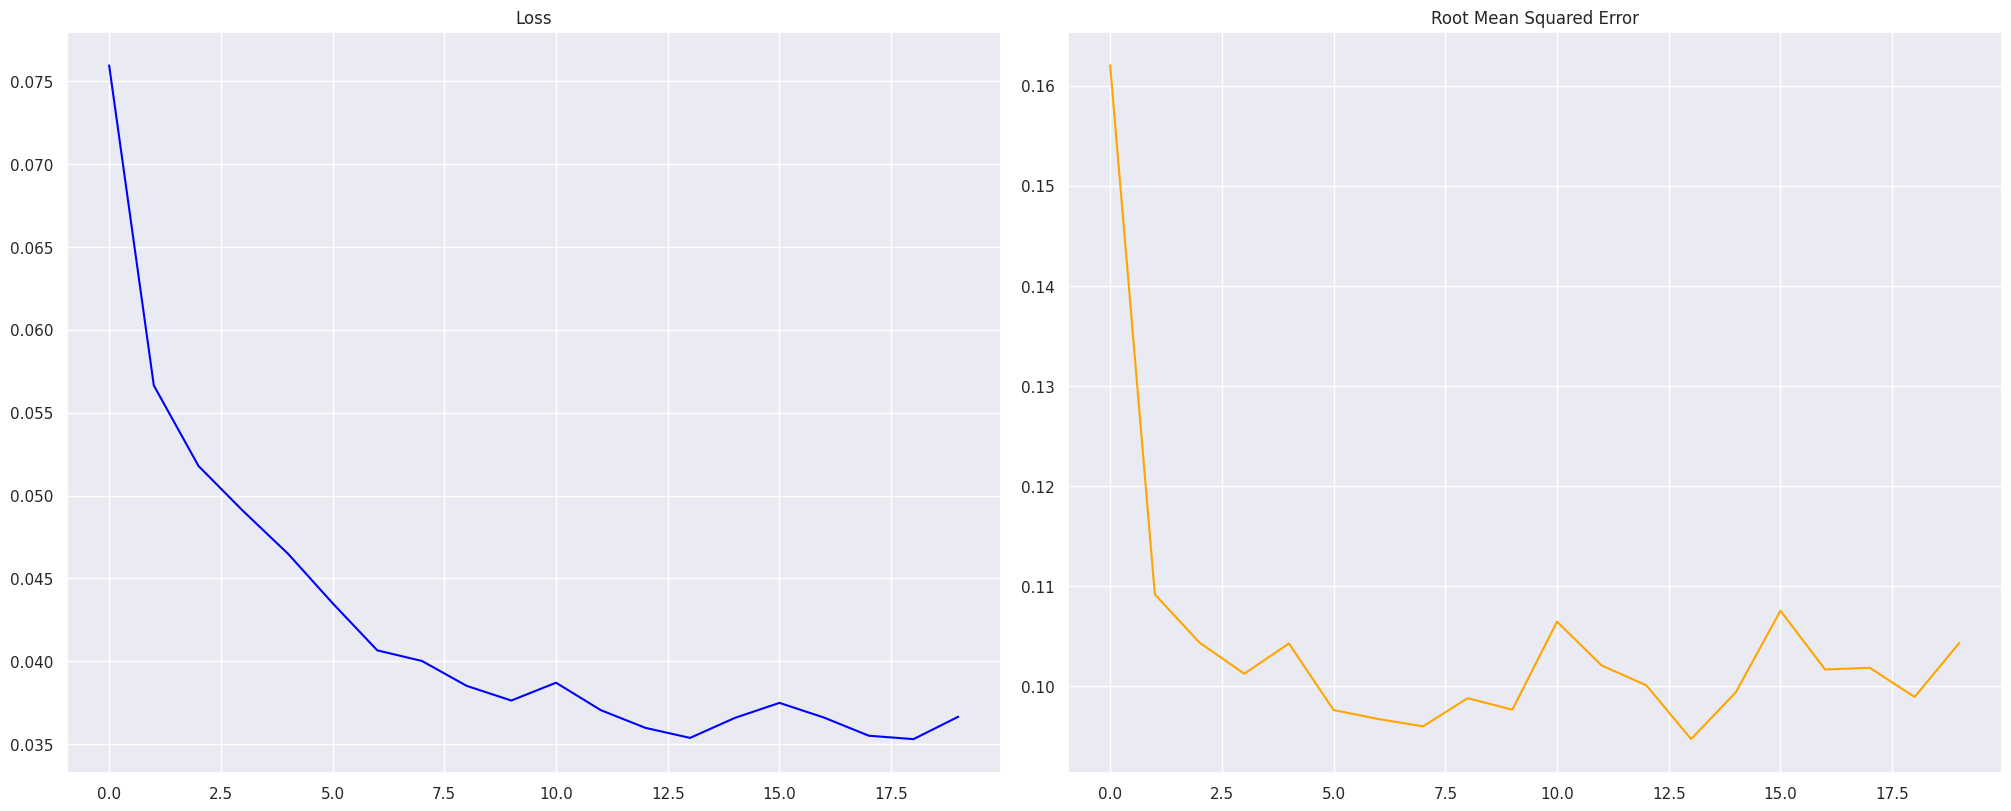

In [16]:
fig, ax = plt.subplots(ncols=2, layout='constrained')

fig.set_figheight(8)
fig.set_figwidth(20)

# Left Plot loss
sns.lineplot(training.history['loss'], color='blue', ax=ax[0])
ax[0].set_title("Loss")

# Left Plot root_mean_squared_error
sns.lineplot(training.history['root_mean_squared_error'], color='orange', ax=ax[1])
ax[1].set_title("Root Mean Squared Error")

In [17]:
# Prep the test data
test_data = scaled_data[training_data_len - 60:]
X_test, y_test = [], dataset[training_data_len:]


for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1 ))

# Make a Prediction
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)


# Plotting data
train = data[:training_data_len]
test =  data[training_data_len:]

test = test.copy()

test['Predictions'] = predictions

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


Text(0.5, 1.0, 'Prediction vs Actual w/o History')

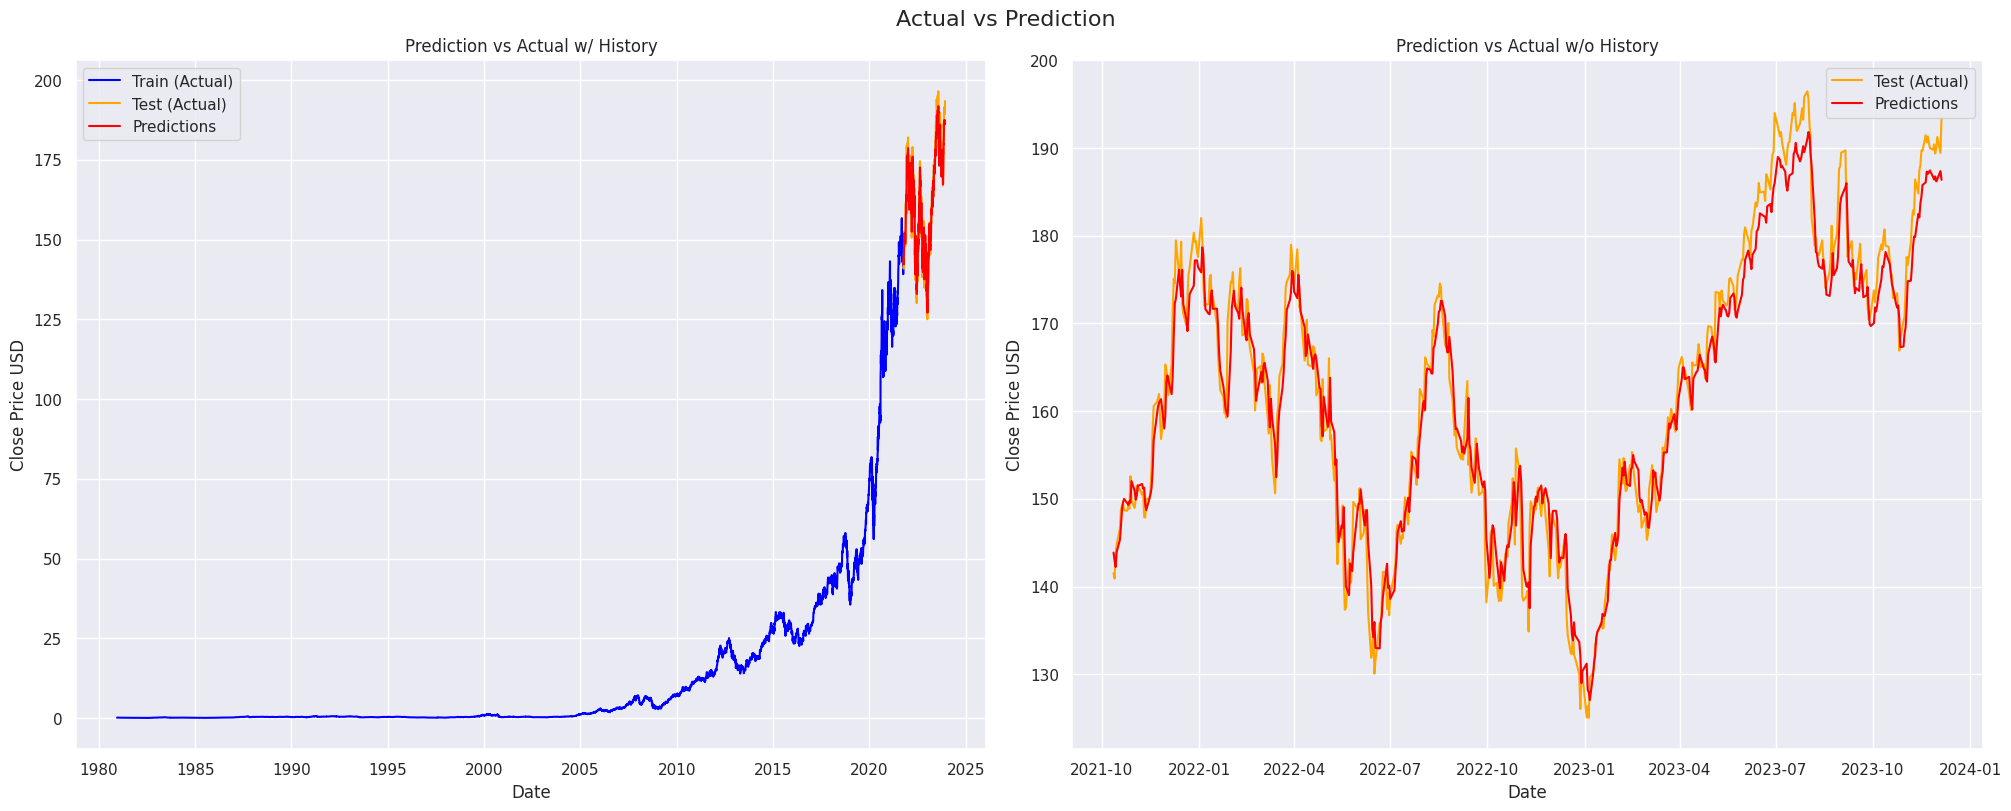

In [18]:
# Plot Predictions
fig, ax = plt.subplots(ncols=2, layout='constrained')

fig.set_figheight(8)
fig.set_figwidth(20)

fig.suptitle('Actual vs Prediction', fontsize=16)

# Left Plot with history
sns.lineplot(x=train['Date'], y=to_usd(train['Close']), label="Train (Actual)", color='blue', ax=ax[0])
sns.lineplot(x=test['Date'], y=to_usd(test['Close']), label="Test (Actual)", color='orange', ax=ax[0])
sns.lineplot(x=test['Date'], y=to_usd(test['Predictions']), label="Predictions", color='red', ax=ax[0])
ax[0].set_ylabel("Close Price USD")
ax[0].set_title("Prediction vs Actual w/ History")

# Left Plot no history
sns.lineplot(x=test['Date'], y=to_usd(test['Close']), label="Test (Actual)", color='orange', ax=ax[1])
sns.lineplot(x=test['Date'], y=to_usd(test['Predictions']), label="Predictions", color='red', ax=ax[1])
ax[1].set_ylabel("Close Price USD")
ax[1].set_title("Prediction vs Actual w/o History")

Text(0, 0.5, 'Relative Error')

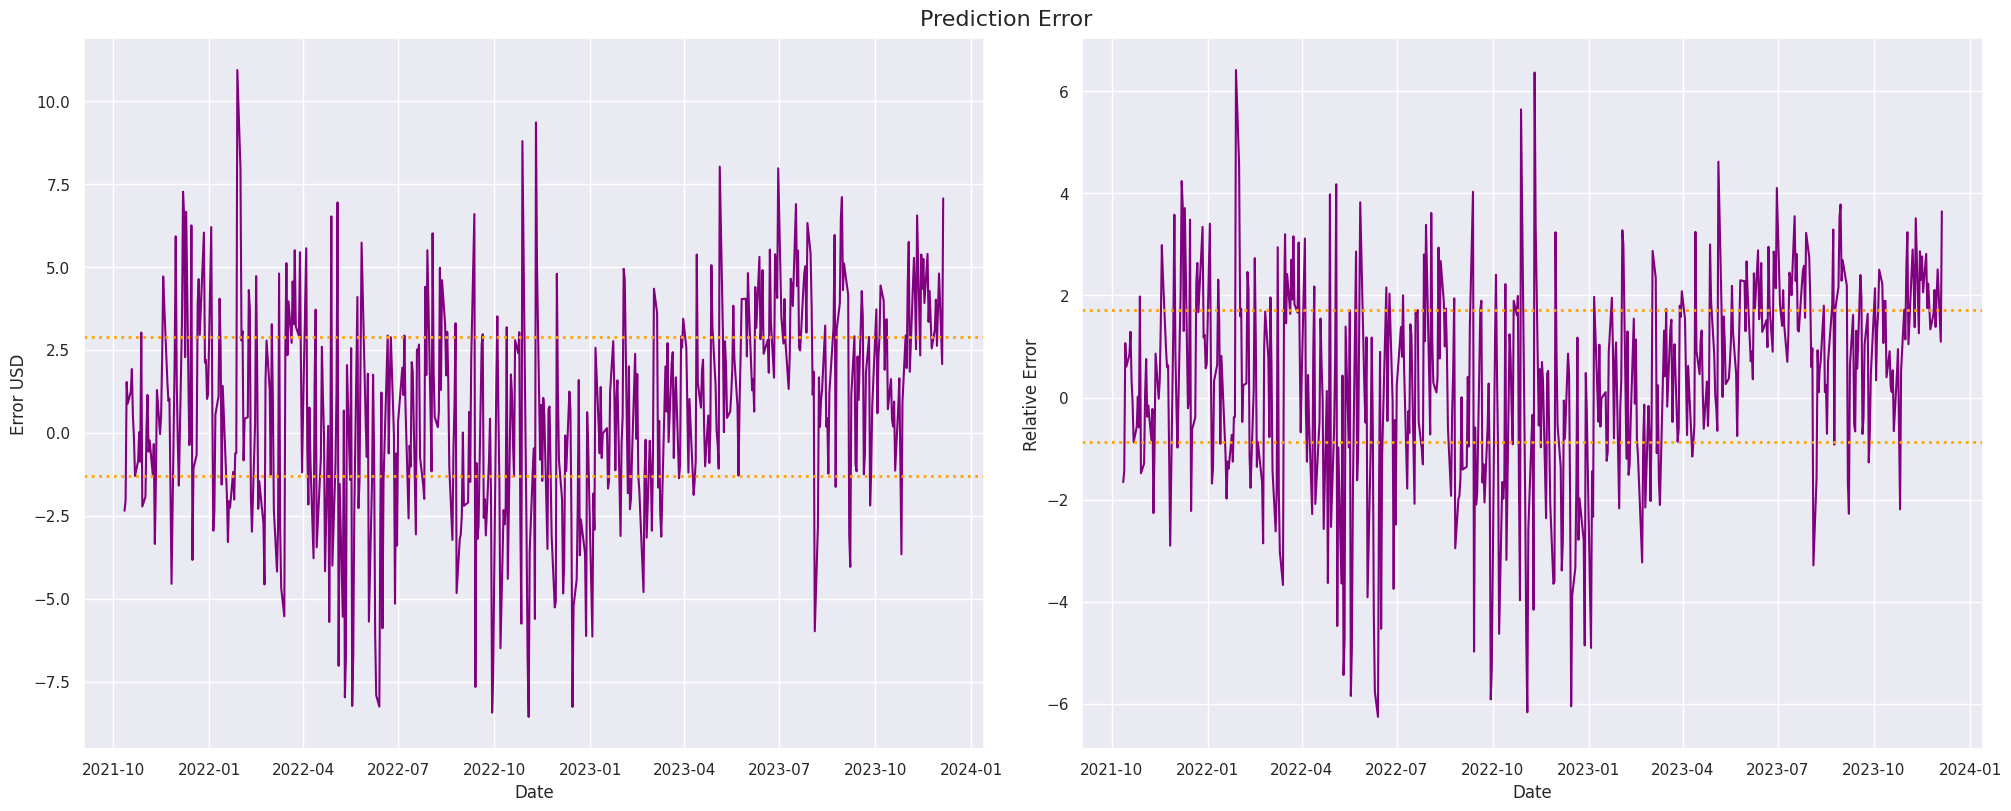

In [19]:
test['Error_usd'] = to_usd(test['Close'] - test['Predictions'])
test['Error_pct'] = ((test['Close'] - test['Predictions']) / test['Close']) * 100

err_usd_desc = test['Error_usd'].describe().to_dict()
err_pct_desc = test['Error_pct'].describe().to_dict()


# Plot Error
fig, ax = plt.subplots(ncols=2, layout='constrained')

fig.set_figheight(8)
fig.set_figwidth(20)

fig.suptitle('Prediction Error', fontsize=16)

# Left Plot with history
sns.lineplot(x=test['Date'], y=test['Error_usd'], color='purple', ax=ax[0])
ax[0].set_ylabel("Error USD")
ax[0].axhline(y=err_usd_desc['25%'], linewidth=2, color='orange', ls=':')
ax[0].axhline(y=err_usd_desc['75%'], linewidth=2, color='orange', ls=':')

# Left Plot no history
sns.lineplot(x=test['Date'], y=test['Error_pct'], color='purple', ax=ax[1])
ax[1].axhline(y=err_pct_desc['25%'], linewidth=2, color='orange', ls=':')
ax[1].axhline(y=err_pct_desc['75%'], linewidth=2, color='orange', ls=':')
ax[1].set_ylabel("Relative Error")

Text(0, 0.5, 'Relative Error')

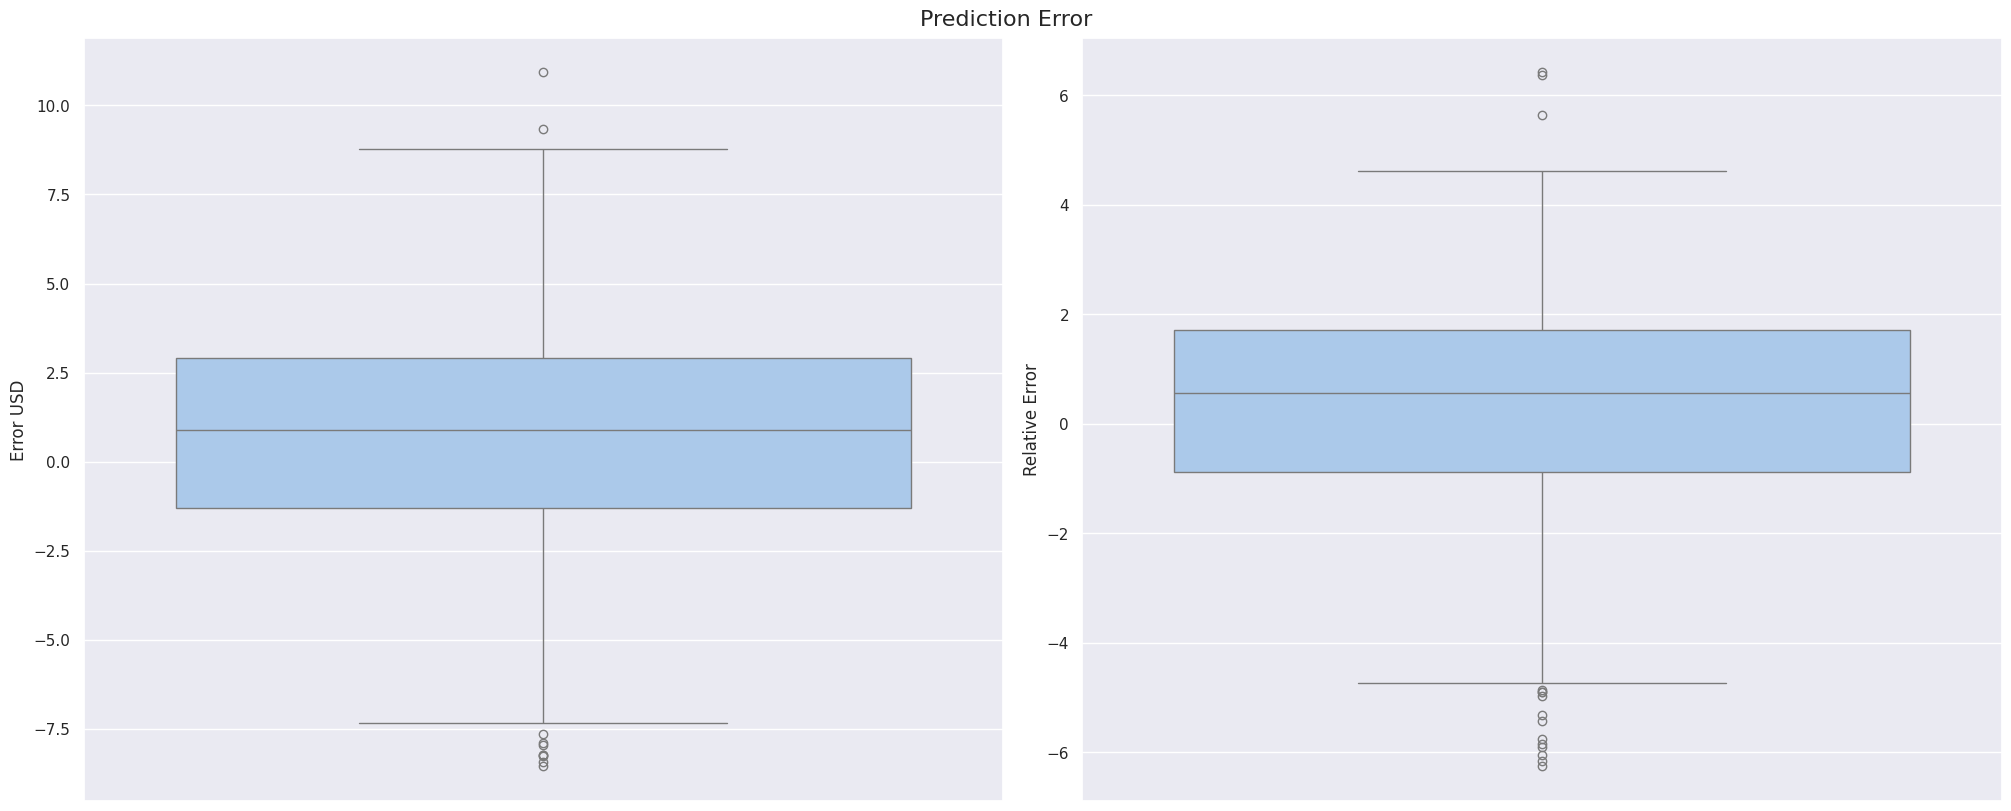

In [20]:
# Boxplot Error
fig, ax = plt.subplots(ncols=2, layout='constrained')

fig.set_figheight(8)
fig.set_figwidth(20)


fig.suptitle('Prediction Error', fontsize=16)

sns.boxplot(test, y="Error_usd", ax=ax[0])
ax[0].set_ylabel("Error USD")

sns.boxplot(test, y="Error_pct", ax=ax[1])
ax[1].set_ylabel("Relative Error")